In [1]:
# alle Export-CSVs der Chrome Extension zusammenführen
import glob
import csv

files = sorted(glob.glob("export_*.csv"))

all_reviews = []
seen_ids = set()
header = None

for f in files:
    with open(f, encoding="utf-8") as fh:
        reader = csv.reader(fh)
        rows = list(reader)
        if header is None:
            header = rows[0]
        for r in rows[1:]:
            # geschwärzte Zeilen und Free-Tier-Hinweis rausfiltern
            if len(r) > 1 and r[0] and not r[0].startswith("#") and r[0] != "Get Unlimited to see more than 10 rows.":
                if r[0] not in seen_ids:
                    seen_ids.add(r[0])
                    all_reviews.append(r)

print(f"Dateien verarbeitet: {len(files)}")
print(f"Einzigartige Bewertungen: {len(all_reviews)}")

# zusammengeführte CSV speichern
with open("sbb_reviews_merged.csv", "w", newline="", encoding="utf-8") as out:
    writer = csv.writer(out)
    writer.writerow(header)
    writer.writerows(all_reviews)

print("Gespeichert als sbb_reviews_merged.csv")

Dateien verarbeitet: 8
Einzigartige Bewertungen: 70
Gespeichert als sbb_reviews_merged.csv


In [9]:
import pandas as pd

df = pd.read_csv("sbb_reviews_merged.csv")
print(df.shape)
df.head(50)

(70, 18)


,id,Review Title,Review Text,Review Rating,Review Date,Review Language,Review Likes,Review Verified,Review Source,Review Source Name,Review Experience Date,Review Updated Date,Reviewer Name,Reviewer Image,Reviewer Country,Reviewer Review Count,Company Reply,Company Reply Date
0,6a3e85542b41ba03f1f71f1c,Klara kenyeresi ist die beste kellnerin…,Klara kenyeresi ist die beste kellnerin in Res...,5,2026-06-26T15:57:40.000Z,de,0,No,invitation,Organic,2026-06-26T00:00:00.000Z,Not Available,Tamás Gazda,Not Available,CH,2,Not Available,Not Available
1,6a3d5bd5a4be4857621fff48,Eigentlich müsste es möglich sein 0…,Eigentlich müsste es möglich sein 0 Sterne zu ...,1,2026-06-25T18:48:21.000Z,de,0,No,invitation,Organic,2026-06-25T00:00:00.000Z,Not Available,Marco Zahn,https://user-images.trustpilot.com/5ccc1b6ce00...,CH,15,Not Available,Not Available
2,6a3d488ce4628a63abe93d57,Absoluter Witz,SBB so beschissen wie die deutsche Bahn. Keine...,1,2026-06-25T17:26:04.000Z,de,2,No,invitation,Organic,2026-06-25T00:00:00.000Z,Not Available,Jasmin Ortner,https://user-images.trustpilot.com/66b1ea106e6...,CH,1,Not Available,Not Available
3,6a3d2eac39598b5112ba3908,Unglsublich zug im ausland 1h…,Unglsublich zug im ausland 1h verspätung wir d...,1,2026-06-25T15:35:40.000Z,de,0,No,invitation,Organic,2026-06-25T00:00:00.000Z,Not Available,Sanja Sp,https://user-images.trustpilot.com/6a3d2ea20a1...,CH,1,Not Available,Not Available
4,6a3bf6c97e2be6e53e72e0d4,Teuer und beschissen. SBB,Teuer und beschissen.. und jedes Jahr noch teu...,1,2026-06-24T17:24:57.000Z,de,1,No,invitation,Organic,2026-06-24T00:00:00.000Z,Not Available,D.Who,https://user-images.trustpilot.com/6a3bf61a937...,CH,1,Not Available,Not Available
5,6a3bf0feafdae40a814603f8,35 °C draussen und keine Klimaanlage,"35 °C draussen, überfüllte Züge und keine funk...",1,2026-06-24T17:00:14.000Z,de,1,No,invitation,Organic,2026-06-24T00:00:00.000Z,Not Available,Night Owl,https://user-images.trustpilot.com/67c2ce050d8...,CH,2,Not Available,Not Available
6,6a3bdb4ce8ca1d060a541bd9,Immer wieder keine Klimaanlage die im…,Immer wieder keine Klimaanlage die im Zug funk...,1,2026-06-24T15:27:41.000Z,de,1,No,invitation,Organic,2026-06-24T00:00:00.000Z,Not Available,Stefan Principe,Not Available,CH,6,Not Available,Not Available
7,6a3b19168483fc8a265b869f,Ich möchte mich über den Kundenservice…,Ich möchte mich über den Kundenservice Ihrer H...,1,2026-06-24T01:39:02.000Z,de,0,No,invitation,Organic,2026-06-24T00:00:00.000Z,Not Available,Jasmin Bühler,https://user-images.trustpilot.com/6a3b190eb90...,CH,1,Not Available,Not Available
8,6a3ab915982ec252356cb5d3,Jede Tag mehr Verspätungen,"Jede Tag mehr Verspätungen, Gleis Änderungen m...",3,2026-06-23T18:49:25.000Z,de,0,No,invitation,Organic,2026-06-23T00:00:00.000Z,Not Available,Barbara Abegg-Baldan,https://user-images.trustpilot.com/6627dde2ce8...,CH,4,Not Available,Not Available
9,6a3a423fc4ee472951ec7038,Warum hat die SBB über die letzten 10…,Warum hat die SBB über die letzten 10 Jahre sy...,2,2026-06-23T10:22:23.000Z,de,0,No,invitation,Organic,2026-06-23T00:00:00.000Z,Not Available,Toni Production,https://user-images.trustpilot.com/6a3a42373d3...,CH,1,Not Available,Not Available


In [17]:
df.columns.tolist()
df.dtypes

id                        object
Review Title              object
Review Text               object
Review Rating              int64
Review Date               object
Review Language           object
Review Likes               int64
Review Verified           object
Review Source             object
Review Source Name        object
Review Experience Date    object
Review Updated Date       object
Reviewer Name             object
Reviewer Image            object
Reviewer Country          object
Reviewer Review Count      int64
Company Reply             object
Company Reply Date        object
dtype: object

In [23]:
df_clean = df[["id", "Review Title", "Review Text", "Review Rating", "Review Date"]].copy()
df_clean.head()

,id,Review Title,Review Text,Review Rating,Review Date
0,6a3e85542b41ba03f1f71f1c,Klara kenyeresi ist die beste kellnerin…,Klara kenyeresi ist die beste kellnerin in Res...,5,2026-06-26T15:57:40.000Z
1,6a3d5bd5a4be4857621fff48,Eigentlich müsste es möglich sein 0…,Eigentlich müsste es möglich sein 0 Sterne zu ...,1,2026-06-25T18:48:21.000Z
2,6a3d488ce4628a63abe93d57,Absoluter Witz,SBB so beschissen wie die deutsche Bahn. Keine...,1,2026-06-25T17:26:04.000Z
3,6a3d2eac39598b5112ba3908,Unglsublich zug im ausland 1h…,Unglsublich zug im ausland 1h verspätung wir d...,1,2026-06-25T15:35:40.000Z
4,6a3bf6c97e2be6e53e72e0d4,Teuer und beschissen. SBB,Teuer und beschissen.. und jedes Jahr noch teu...,1,2026-06-24T17:24:57.000Z


In [29]:
df_clean.columns.tolist()
df_clean.dtypes

id               object
Review Title     object
Review Text      object
Review Rating     int64
Review Date      object
dtype: object

In [31]:
df_clean.isnull().sum()


id               0
Review Title     0
Review Text      0
Review Rating    0
Review Date      0
dtype: int64

In [33]:
from transformers import pipeline

# pipeline lädt ein vortrainiertes modell direkt von huggingface
# "oliverguhr/german-sentiment-bert" ist speziell auf deutschen texten trainiert
# wichtig weil unsere bewertungen auf deutsch (mit schweizer einschlag) sind
# beim ersten ausführen wird das modell heruntergeladen (~400mb), danach gecacht

sentiment_model = pipeline(
    "sentiment-analysis",
    model="oliverguhr/german-sentiment-bert"
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use mps:0


In [34]:
# test an einer einzelnen bewertung
beispiel = df_clean["Review Text"].iloc[0]
print(beispiel)
print(sentiment_model(beispiel))

Klara kenyeresi ist die beste kellnerin in Restaurantwagen! Fleissig und Freundlich!! Ic 3 Zürich-Basel.
Danke!
[{'label': 'positive', 'score': 0.9641104936599731}]


In [35]:
print(sentiment_model)

In [39]:
# über alle bewertungen iterieren
# .apply() wendet die funktion auf jede zeile der spalte an
# lambda extrahiert nur label und score aus dem rückgabe-dict

results = df_clean["Review Text"].apply(lambda text: sentiment_model(text[:512])[0])

df_clean["sentiment"] = results.apply(lambda r: r["label"])
df_clean["confidence"] = results.apply(lambda r: r["score"])

df_clean.head(10)


,id,Review Title,Review Text,Review Rating,Review Date,sentiment,confidence
0,6a3e85542b41ba03f1f71f1c,Klara kenyeresi ist die beste kellnerin…,Klara kenyeresi ist die beste kellnerin in Res...,5,2026-06-26T15:57:40.000Z,positive,0.964110
1,6a3d5bd5a4be4857621fff48,Eigentlich müsste es möglich sein 0…,Eigentlich müsste es möglich sein 0 Sterne zu ...,1,2026-06-25T18:48:21.000Z,negative,0.994320
2,6a3d488ce4628a63abe93d57,Absoluter Witz,SBB so beschissen wie die deutsche Bahn. Keine...,1,2026-06-25T17:26:04.000Z,negative,0.998760
3,6a3d2eac39598b5112ba3908,Unglsublich zug im ausland 1h…,Unglsublich zug im ausland 1h verspätung wir d...,1,2026-06-25T15:35:40.000Z,negative,0.996524
4,6a3bf6c97e2be6e53e72e0d4,Teuer und beschissen. SBB,Teuer und beschissen.. und jedes Jahr noch teu...,1,2026-06-24T17:24:57.000Z,negative,0.998434
5,6a3bf0feafdae40a814603f8,35 °C draussen und keine Klimaanlage,"35 °C draussen, überfüllte Züge und keine funk...",1,2026-06-24T17:00:14.000Z,negative,0.999709
6,6a3bdb4ce8ca1d060a541bd9,Immer wieder keine Klimaanlage die im…,Immer wieder keine Klimaanlage die im Zug funk...,1,2026-06-24T15:27:41.000Z,negative,0.992898
7,6a3b19168483fc8a265b869f,Ich möchte mich über den Kundenservice…,Ich möchte mich über den Kundenservice Ihrer H...,1,2026-06-24T01:39:02.000Z,negative,0.999527
8,6a3ab915982ec252356cb5d3,Jede Tag mehr Verspätungen,"Jede Tag mehr Verspätungen, Gleis Änderungen m...",3,2026-06-23T18:49:25.000Z,negative,0.987070
9,6a3a423fc4ee472951ec7038,Warum hat die SBB über die letzten 10…,Warum hat die SBB über die letzten 10 Jahre sy...,2,2026-06-23T10:22:23.000Z,negative,0.931469


In [41]:
df_clean["sentiment"].value_counts()

sentiment
negative    62
positive     5
neutral      3
Name: count, dtype: int64

In [43]:
from collections import Counter
import re

# stopwords - deutsche füllwörter die wir nicht zählen wollen
stopwords_de = {
    "der", "die", "das", "und", "ist", "war", "ich", "es", "in", "zu", "den",
    "mit", "auf", "für", "von", "im", "nicht", "ein", "eine", "auch", "an",
    "als", "bei", "wie", "sich", "wird", "wurde", "haben", "hat", "sind",
    "man", "nur", "noch", "schon", "so", "aber", "wenn", "dass", "sehr", "mich",
    "mir", "wir", "sie", "er", "des", "dem", "zum", "zur", "vom"
}

def get_words(text):
    text = text.lower()
    words = re.findall(r"\b[a-zäöüß]+\b", text)
    return [w for w in words if w not in stopwords_de and len(w) > 2]

# alle wörter aus negativen bewertungen sammeln
negative_texts = df_clean[df_clean["sentiment"] == "negative"]["Review Text"]
all_words = []
for text in negative_texts:
    all_words.extend(get_words(text))

word_counts = Counter(all_words)
print("Top 20 Wörter in negativen Bewertungen:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Top 20 Wörter in negativen Bewertungen:
sbb: 37
habe: 36
zug: 28
über: 16
dann: 16
keine: 15
nach: 15
werden: 14
ticket: 14
einen: 13
einem: 12
mehr: 12
kann: 12
was: 11
app: 11
wieder: 10
immer: 10
jetzt: 10
zürich: 10
möchte: 9


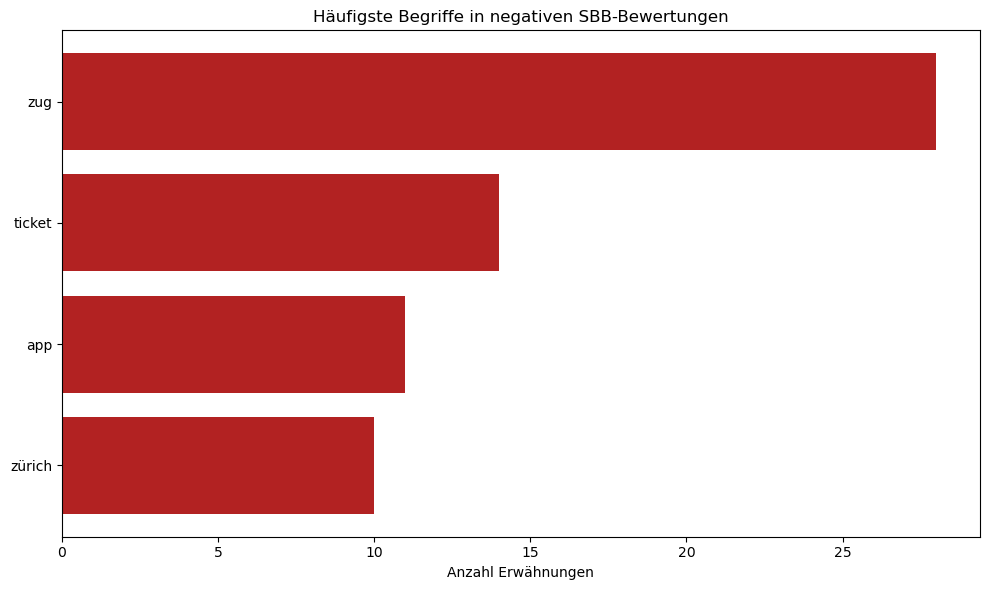

In [45]:
import matplotlib.pyplot as plt

# top 15 wörter ohne "sbb" und "habe" - die sind zu generisch
top_words = [w for w, c in word_counts.most_common(20) if w not in ["sbb", "habe", "über", "dann", "nach", "einen", "einem", "was", "kann", "mehr", "werden", "wieder", "immer", "jetzt", "möchte", "keine"]]
top_counts = [word_counts[w] for w in top_words]

plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], top_counts[::-1], color="firebrick")
plt.title("Häufigste Begriffe in negativen SBB-Bewertungen")
plt.xlabel("Anzahl Erwähnungen")
plt.tight_layout()
plt.show()

In [47]:
from collections import Counter

def get_bigrams(text):
    words = get_words(text)
    return list(zip(words, words[1:]))

all_bigrams = []
for text in negative_texts:
    all_bigrams.extend(get_bigrams(text))

bigram_counts = Counter(all_bigrams)
print("Top 15 Wortpaare in negativen Bewertungen:")
for pair, count in bigram_counts.most_common(15):
    print(f"{pair[0]} {pair[1]}: {count}")

Top 15 Wortpaare in negativen Bewertungen:
immer wieder: 5
sbb app: 4
nach zürich: 4
jedes jahr: 3
mein ticket: 3
schalter gehen: 3
habe mein: 3
über sbb: 3
jahr steigen: 2
seine kunden: 2
grundlegender komfort: 2
komfort gewährleistet: 2
klimaanlage zug: 2
keine entschuldigung: 2
mehr verlängern: 2


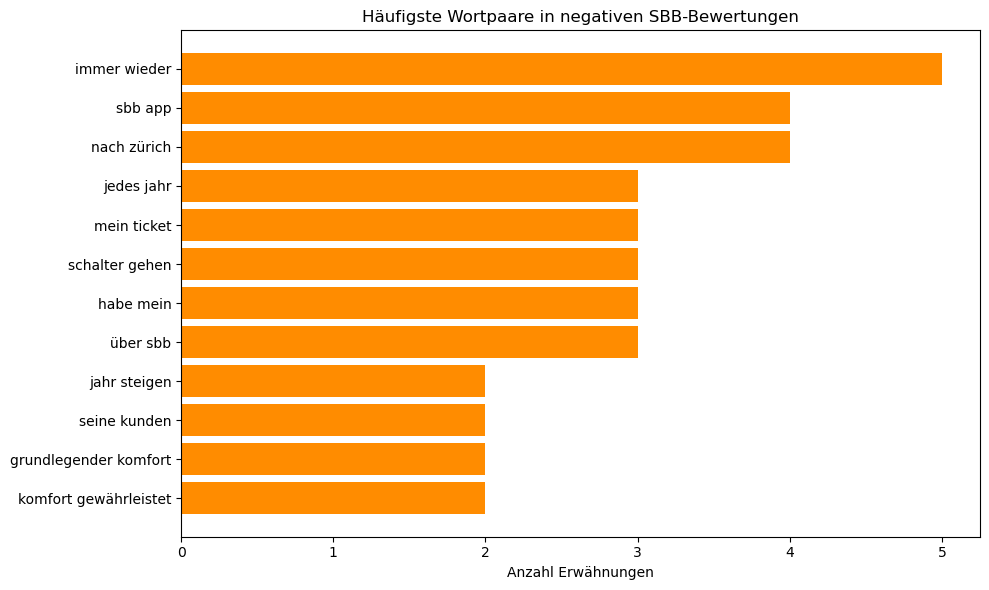

In [49]:
top_bigrams = bigram_counts.most_common(12)
labels = [f"{a} {b}" for (a, b), c in top_bigrams]
counts = [c for (a, b), c in top_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], counts[::-1], color="darkorange")
plt.title("Häufigste Wortpaare in negativen SBB-Bewertungen")
plt.xlabel("Anzahl Erwähnungen")
plt.tight_layout()
plt.show()